In [1]:
import sys

if "google.colab" in sys.modules:
    # Mount Google Drive
    from google.colab import drive
    drive.mount('/content/drive')
    original_data = '/content/drive/My Drive/MS1/original_dataset'
    final_data = '/content/drive/My Drive/MS1/Final_Dataset'

    # Install required packages
    !pip install pymatgen torch_geometric mp_api

else:
    original_data = "original_dataset"
    final_data = "Final_Dataset"

In [ ]:
"""# Get formation energy of all elements in the periodiic table
from mp_api.client import MPRester
import numpy as np
from pymatgen.core.periodic_table import Element


all_elements = [str(el) for el in Element]

API_KEY = ""

def get_formation(element, API_KEY):
    with MPRester(API_KEY) as mpr:
        results = mpr.materials.summary.search(
            elements=[element],
            num_elements=1,
            fields= ["energy_per_atom"]
        )
        forms_list = [result.energy_per_atom for result in results]
        avg_formation_energy = np.mean(forms_list)

    return avg_formation_energy

formation_energies = {element: get_formation(element, API_KEY) for element in all_elements}
print(formation_energies)"""

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader


from pymatgen.core import Structure, PeriodicSite, DummySpecie, Composition, Element
from pymatgen.core.periodic_table import Element as PMGElement
from pymatgen.analysis.local_env import MinimumDistanceNN, CrystalNN, VoronoiNN
# from mp_api.client import MPRester
from pymatgen.symmetry.analyzer import SpacegroupAnalyzer
from sklearn.model_selection import train_test_split

# import json
import config
import graphy_gnn


API_KEY = "Not relevant right now"  # Replace with your Materials Project API key


/home/amutua/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [4]:
comb_df = pd.read_csv(f"{final_data}/combined/combined_data.csv")
train_graphs = torch.load(f"{final_data}/train_graphs.pt", weights_only=False)
test_graphs = torch.load(f"{final_data}/test_graphs.pt", weights_only=False)
val_graphs = torch.load(f"{final_data}/val_graphs.pt", weights_only=False)

# Sample row
sample_row = comb_df.iloc[0]

# Get defective structure
material = sample_row["dataset_material"]
id = sample_row["_id"]

# Get defective structure
defective_file_path = f"{original_data}/{material}/cifs/{id}.cif"
defective_structure = Structure.from_file(defective_file_path)

# Get reference structure
ref_file_path = f"{final_data}/ref_cifs/{material}.cif"
reference_structure = Structure.from_file(ref_file_path)

/home/amutua/.local/lib/python3.10/site-packages/pymatgen/core/structure.py:3109: UserWarning: Issues encountered while parsing CIF: 32 fractional coordinates rounded to ideal values to avoid issues with finite precision.
  struct = parser.parse_structures(primitive=primitive)[0]


In [9]:
# Test graphy_gnn functions
defects_structure = graphy_gnn.get_defects_structure(defective_structure, reference_structure)

nodes = graphy_gnn.get_nodes(defects_structure)
edges, edge_features = graphy_gnn.get_edges_and_features(reference_structure, defects_structure)
global_features = graphy_gnn.get_globals(reference_structure, defective_structure, defects_structure)

print("Nodes:", nodes)
print("Edges:", edges)
print("Edge Features:", edge_features)
print("Global Features:", global_features)


Nodes: [[np.float64(54.666088403202025), 1, -0.15000000000000002, 0.5099999999999998, 1, -0.10999999999999999, 6, 0.7, 1.262122611, 2.55, 14, 0.41, 4, 2, 5, 0.85, 0.27972325, 2.04, 13, 0.41, 3, 2, 0, 0.0, 0.0, 1.0, -2.522000000000001], [np.float64(54.66608694544373), 1, -0.15000000000000002, 0.5099999999999998, 1, -0.10999999999999999, 6, 0.7, 1.262122611, 2.55, 14, 0.41, 4, 2, 5, 0.85, 0.27972325, 2.04, 13, 0.41, 3, 2, 0, 0.0, 0.0, 1.0, -2.522000000000001], [np.float64(54.66608694544392), -7, -0.65, -3.04, -15, -0.63, 0, 0.0, 0.0, 0.0, 0, 0.0, 0, 0, 7, 0.65, -0.07, 3.04, 15, 0.63, 5, 2, -2, 3, 1.0, 0.0, 8.324]]
Edges: [[0, 0, 1], [1, 2, 2]]
Edge Features: [[13.98860945246643, np.float64(6.647261259887691), 0.6959705358369901, 6.360484000000006, -5.044000000000002, 0.0, 16, 1.1437877406162718, 0.012099999999999998, 4.420401671366696e-06, np.float64(1.0), 0, 1, 0], [15.134745243136157, np.float64(5.241317743503728), 0.752993840625424, -20.99312800000001, 5.801999999999999, 10.846, 0, 0.

In [38]:
# Create graph representation of the structures
def graphy(row, reference_structure):
    material = row["dataset_material"]
    id = row["_id"]
    defective_structure = Structure.from_file(f"{original_data}/{material}/cifs/{id}.cif")

    defects_structure = graphy_gnn.get_defects_structure(defective_structure, reference_structure)

    nodes = graphy_gnn.get_nodes(defects_structure)
    edges, edge_features = graphy_gnn.get_edges_and_features(reference_structure, defects_structure)
    global_features = graphy_gnn.get_globals(reference_structure, defective_structure, defects_structure)

    target = row["band_gap_value"]

    the_data = Data(
        x=torch.tensor(nodes, dtype=torch.float),
        edge_index=torch.tensor(edges, dtype=torch.long),
        edge_attr=torch.tensor(edge_features, dtype=torch.float),
        u=torch.tensor(global_features, dtype=torch.float).unsqueeze(0),
        y=torch.tensor(target, dtype=torch.float).unsqueeze(0)
    )
    return the_data

def fast_grapy(dataset):
    graph_list = []
    unique_dataset_materials = dataset["dataset_material"].unique()

    all_mat = len(unique_dataset_materials)

    for i in unique_dataset_materials:
        subset = dataset[dataset["dataset_material"] == i].reset_index(drop=True)
        all_rows = len(subset)

        pristine_structure = Structure.from_file(f"{final_data}/ref_cifs/{i}.cif")
        
        # Go through every row in the subset
        for index, row in subset.iterrows():
            data = graphy(row, pristine_structure)

            # Track progress
            if index % 10 == 0:  # Print progress every 10 rows
                print(f"material {i} ({index+1}/{all_rows}) - {((index+1)/all_rows)*100:.2f}% complete")
            
            # Put all graphs together in a list
            graph_list.append(data)
            
    return graph_list

In [39]:
# Split the data
from sklearn.model_selection import train_test_split

train_set, test_set = train_test_split(comb_df, test_size=0.2, stratify=comb_df['strata'], random_state=42)
test_set, val_set = train_test_split(test_set, test_size=0.5, random_state=42)


In [ ]:
# Create graphs for each set
train_graphs = fast_grapy(train_set)
val_graphs = fast_grapy(val_set)
test_graphs = fast_grapy(test_set)

In [41]:
# Save graphs
torch.save(train_graphs, f"{final_data}/train_graphs.pt")
torch.save(val_graphs, f"{final_data}/val_graphs.pt")
torch.save(test_graphs, f"{final_data}/test_graphs.pt")

In [5]:
# Find the graph where the edge features has shape 0 and remove them from the training set

def remove_1_defect_graphs(graphs):
    unwanted = []
    for i, data in enumerate(graphs):
        if data.edge_attr.shape[0] == 0:
            unwanted.append(i)

    new_graphs = [data for i, data in enumerate(graphs) if i not in unwanted]
    return new_graphs

new_train_graphs = remove_1_defect_graphs(train_graphs)
new_val_graphs = remove_1_defect_graphs(val_graphs)
new_test_graphs = remove_1_defect_graphs(test_graphs)

In [93]:
# Create data loaders
train_loader = DataLoader(new_train_graphs, batch_size=1, shuffle=True)
val_loader = DataLoader(new_val_graphs, batch_size=1, shuffle=False)
test_loader = DataLoader(new_test_graphs, batch_size=1, shuffle=False)

In [55]:
# Use data size to determine model architecture
NODE_DIM =train_graphs[0].x.shape[1] # 27
EDGE_DIM =train_graphs[0].edge_attr.shape[1] # 14
HIDDEN_DIM = 128
EMBED_DIM = 64
U_DIM =train_graphs[0].u.shape[1] # 14

# The GNN Model

In [30]:
# import dependancies
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import global_mean_pool, NNConv, CGConv, global_max_pool, GCNConv


In [95]:
# Train model

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def evaluate(model, loader, loss_fn):
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for data in loader:
            data = data.to(device)

            out = model(data)
            loss = loss_fn(out, data.y)

            total_loss += loss.item() * data.num_graphs
    return total_loss / len(loader.dataset)

def train(model, train_loader, val_loader, epochs, optimizer, loss_fn):
    train_losses = []
    val_losses = []

    # Learning rate scheduler to help convergence
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=30, gamma=0.5)

    for epoch in range(1, epochs+1):
        model.train()
        total_loss = 0
        for data in train_loader:
            data = data.to(device)
            optimizer.zero_grad()

            out = model(data)
            loss = loss_fn(out, data.y)

            loss.backward()
            optimizer.step()
            total_loss += loss.item() * data.num_graphs
        train_loss = total_loss / len(train_loader.dataset)
        # train_loss = train(the_model, train_loader, optimizer, loss_fn)
        val_loss = evaluate(model, val_loader, loss_fn)
        scheduler.step()

        print(f'Epoch {epoch:03d}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}')

        train_losses.append(train_loss)
        val_losses.append(val_loss)

    # Test model
    test_loss = evaluate(model, test_loader, loss_fn)
    print(f'Test Loss: {test_loss:.4f}')

    return train_losses, val_losses

def predict(model, loader, actuals=False):
    model.eval()
    if actuals:
        predictions = []
        actual = []
        with torch.no_grad():
            for data in loader:
                data = data.to(device)

                out = model(data)
                predictions.append(out.cpu().numpy())
                actual.append(data.y.cpu().numpy())

        predictions = np.concatenate(predictions, axis=0).flatten()
        actual = np.concatenate(actual, axis=0).flatten()
        return predictions, actual
    else:
        predictions = []
        with torch.no_grad():
            for data in loader:
                data = data.to(device)

                out = model(data)
                predictions.append(out.cpu().numpy())

        predictions = np.concatenate(predictions, axis=0).flatten()
        return predictions

# Informative Graphs
def get_graphs(train_losses, val_losses, the_model):
    fig, axs = plt.subplots(3, 1, figsize=(10, 10))

    axs[0].plot(train_losses, label='Train Loss')
    axs[0].plot(val_losses, label='Validation Loss')
    axs[0].set_xlabel('Epoch')
    axs[0].set_ylabel('Loss')
    axs[0].set_title('Training  and Validation Loss')
    axs[0].legend()

    # model values
    predicted_values, actual_values = predict(the_model, test_loader, actuals=True)


    axs[1].scatter(actual_values, predicted_values )
    axs[1].plot(actual_values, actual_values, c="black")
    axs[1].set_xlabel('Actual Band Gaps(eV)')
    axs[1].set_ylabel('Predicted Band Gaps(eV)')
    axs[1].set_title('Actual vs Predicted Band Gap Values')

    axs[2].plot(actual_values[100:150], label='Actual Values', marker='o')
    axs[2].plot(predicted_values[100:150], label='Predicted Values', marker='o')
    axs[2].set_xlabel('Samples')
    axs[2].set_ylabel('Band gap(eV)')
    axs[2].set_title('Actual vs Predicted Band Gap Values')
    axs[2].legend()

    plt.show()


class LogCoshLoss(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, input, target):
        ey_t = input-target
        return torch.mean(torch.log(torch.cosh(ey_t + 1e-12)))


class RelativeMSELoss(nn.Module):
    def __inti__(self):
        super().__init__()

    def forward(self, y_pred, y_true):
        return torch.mean(((y_pred-y_true)/ (y_true + 1e-8)) ** 2)


class SMAPELoss(nn.Module):
    def __inti__(self):
        super().__init__()

    def forward(self, y_pred, y_true):
        numerator = torch.abs(y_pred - y_true)
        denominator = (torch.abs(y_true) + torch.abs(y_pred))/2.0 + 1e-8
        return torch.mean(numerator/denominator)

# Loss function
# loss_fn = nn.MSELoss()
loss_fn = LogCoshLoss()
# loss_fn = RelativeMSELoss()
# loss_fn = SMAPELoss()

In [ ]:
# Testing architectures
sample_node = torch.rand((3,NODE_DIM))
sample_edges = torch.tensor([[0, 1, 2, 0, 1, 2, 0, 1, 2], [0,0,0,1,1,1,2,2,2]], dtype=torch.long)
sample_edge_attr = torch.rand((9, EDGE_DIM))

# sample_conv1 = CGConv(NODE_DIM, EDGE_DIM)
# out = sample_conv1(sample_node, sample_edges, sample_edge_attr)
# print(out.shape)

sample_x = torch.rand((1,91))

sample_fc = nn.Sequential(
    nn.Linear(NODE_DIM + EMBED_DIM, 128),
    nn.ReLU(),
    nn.Linear(128, 64),
    nn.ReLU(),
    nn.Linear(64, 32),
    nn.ReLU(),
    nn.Linear(32, 1)
)
out = sample_fc(sample_x)
print(out.shape)

41
torch.Size([1, 1])


## Model 1

Epoch 001, Train Loss: 0.0151, Val Loss: 0.0073
Epoch 002, Train Loss: 0.0090, Val Loss: 0.0069
Epoch 003, Train Loss: 0.0081, Val Loss: 0.0079
Epoch 004, Train Loss: 0.0077, Val Loss: 0.0079
Epoch 005, Train Loss: 0.0075, Val Loss: 0.0073
Epoch 006, Train Loss: 0.0075, Val Loss: 0.0071
Epoch 007, Train Loss: 0.0073, Val Loss: 0.0074
Epoch 008, Train Loss: 0.0071, Val Loss: 0.0066
Epoch 009, Train Loss: 0.0072, Val Loss: 0.0069
Epoch 010, Train Loss: 0.0072, Val Loss: 0.0069
Epoch 011, Train Loss: 0.0073, Val Loss: 0.0067
Epoch 012, Train Loss: 0.0070, Val Loss: 0.0067
Epoch 013, Train Loss: 0.0072, Val Loss: 0.0067
Epoch 014, Train Loss: 0.0071, Val Loss: 0.0066
Epoch 015, Train Loss: 0.0072, Val Loss: 0.0085
Epoch 016, Train Loss: 0.0073, Val Loss: 0.0065
Epoch 017, Train Loss: 0.0071, Val Loss: 0.0074
Epoch 018, Train Loss: 0.0070, Val Loss: 0.0090
Epoch 019, Train Loss: 0.0074, Val Loss: 0.0071
Epoch 020, Train Loss: 0.0073, Val Loss: 0.0068
Test Loss: 0.0070


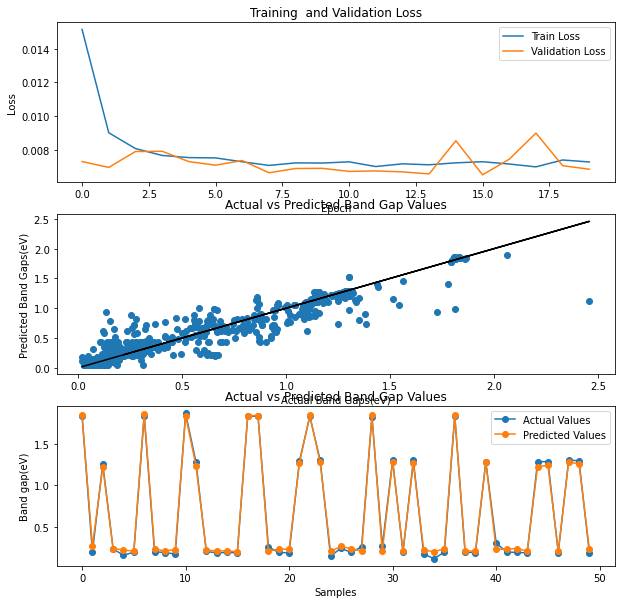

In [96]:
class GNNModelCG(nn.Module):
    def __init__(self, node_dim=NODE_DIM, edge_dim=EDGE_DIM, hidden_dim=HIDDEN_DIM, embed_dim=EMBED_DIM, u_dim=U_DIM):
        super().__init__()
        self.conv1 = CGConv(node_dim, edge_dim, aggr='mean') # , batch_norm=True)
        # self.conv2 = CGConv(edge_dim, edge_dim, aggr='mean', batch_norm=True)

        self.global_embed = nn.Linear(u_dim, embed_dim)

        self.fc = nn.Sequential(
            nn.Linear(node_dim + embed_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1),
        )

    def forward(self, data):
        x, edge_index, edge_attr, batch, u = (
            data.x,
            data.edge_index,
            data.edge_attr,
            data.batch,
            data.u,
        )
        # print("New forward pass")
        # print(x.shape, edge_index.shape, edge_attr.shape, batch.shape, u.shape)

        x = F.relu(self.conv1(x, edge_index, edge_attr))
        # print(x.shape, edge_index.shape, edge_attr.shape, batch.shape, u.shape)

        # x = F.relu(self.conv2(x, edge_index, edge_attr))
        # print(x.shape, edge_index.shape, edge_attr.shape, batch.shape, u.shape)

        x = global_mean_pool(x, batch)
        # print(x.shape, edge_index.shape, edge_attr.shape, batch.shape, u.shape)

        u = self.global_embed(u)
        # print(x.shape, edge_index.shape, edge_attr.shape, batch.shape, u.shape)

        x = torch.cat([x, u], dim=1)
        # print(x.shape, edge_index.shape, edge_attr.shape, batch.shape, u.shape)

        the_return = self.fc(x)
        return the_return

# Use the CGConv-only model if you want a simpler graph architecture.
GNN_model_cg = GNNModelCG().to(device)

# optimizer
optimizer = torch.optim.Adam(GNN_model_cg.parameters(), lr=0.001)

# Train the model
train_losses, val_losses = train(GNN_model_cg, train_loader, val_loader, epochs=20, optimizer=optimizer, loss_fn=loss_fn)
get_graphs(train_losses, val_losses, GNN_model_cg)

## Model 2

Epoch 001, Train Loss: 0.1043, Val Loss: 0.0477
Epoch 002, Train Loss: 0.0289, Val Loss: 0.0271
Epoch 003, Train Loss: 0.0217, Val Loss: 0.0208
Epoch 004, Train Loss: 0.0165, Val Loss: 0.0138
Epoch 005, Train Loss: 0.0153, Val Loss: 0.0128
Epoch 006, Train Loss: 0.0129, Val Loss: 0.0150
Epoch 007, Train Loss: 0.0115, Val Loss: 0.0116
Epoch 008, Train Loss: 0.0110, Val Loss: 0.0090
Epoch 009, Train Loss: 0.0101, Val Loss: 0.0120
Epoch 010, Train Loss: 0.0091, Val Loss: 0.0118
Epoch 011, Train Loss: 0.0090, Val Loss: 0.0092
Epoch 012, Train Loss: 0.0083, Val Loss: 0.0156
Epoch 013, Train Loss: 0.0084, Val Loss: 0.0072
Epoch 014, Train Loss: 0.0079, Val Loss: 0.0085
Epoch 015, Train Loss: 0.0076, Val Loss: 0.0104
Epoch 016, Train Loss: 0.0073, Val Loss: 0.0069
Epoch 017, Train Loss: 0.0072, Val Loss: 0.0081
Epoch 018, Train Loss: 0.0070, Val Loss: 0.0073
Epoch 019, Train Loss: 0.0068, Val Loss: 0.0068
Epoch 020, Train Loss: 0.0068, Val Loss: 0.0069
Test Loss: 0.0073


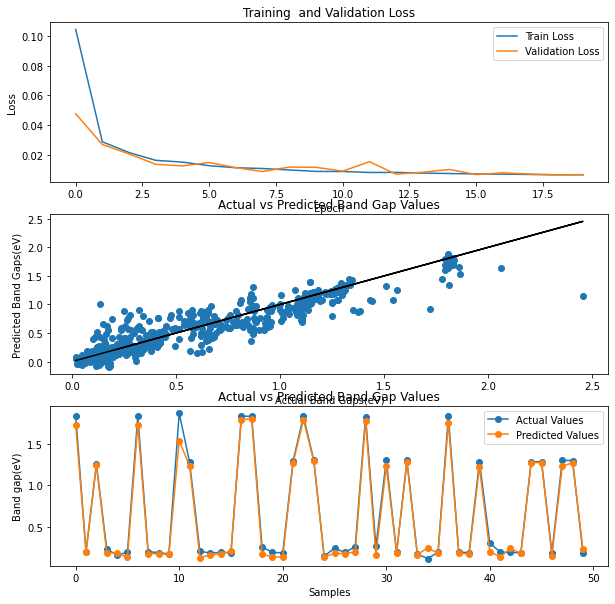

In [97]:
class Model2(nn.Module):
    def __init__(self, node_dim=NODE_DIM, edge_dim=EDGE_DIM, hidden_dim=HIDDEN_DIM, embed_dim=EMBED_DIM, u_dim=U_DIM):
        super().__init__()

        # For the edges
        self.edge_nn = nn.Sequential(
            nn.Linear(edge_dim, 64),
            nn.ReLU(),
            nn.Linear(64, node_dim * hidden_dim)
        )

        self.conv1 = NNConv(node_dim, hidden_dim, self.edge_nn, aggr='mean')

        # self.conv1 = CGConv(hidden_dim, hidden_dim, aggr='mean')
        self.conv2 = CGConv(hidden_dim, edge_dim, aggr='mean')

        self.global_embed = nn.Linear(u_dim, embed_dim)

        self.fc = nn.Sequential(
            nn.Linear(hidden_dim + embed_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1),
        )

    def forward(self, data):
        x, edge_index, edge_attr, batch, u = (
            data.x,
            data.edge_index,
            data.edge_attr,
            data.batch,
            data.u,
        )
        x = F.relu(self.conv1(x, edge_index, edge_attr))
        x = F.relu(self.conv2(x, edge_index, edge_attr))

        x = global_mean_pool(x, batch)

        u = self.global_embed(u)

        x = torch.cat([x, u], dim=1)
        the_return = self.fc(x)
        return the_return

# Use the CGConv-only model if you want a simpler graph architecture.
model_2 = Model2().to(device)

# optimizer
optimizer = torch.optim.Adam(model_2.parameters(), lr=0.00001)

# Train this model
train_losses, val_losses = train(model_2, train_loader, val_loader, epochs=20, optimizer=optimizer, loss_fn=loss_fn)
get_graphs(train_losses, val_losses, model_2)

## Model 3

Epoch 001, Train Loss: 0.0429, Val Loss: 0.0141
Epoch 002, Train Loss: 0.0229, Val Loss: 0.0209
Epoch 003, Train Loss: 0.0205, Val Loss: 0.0139
Epoch 004, Train Loss: 0.0206, Val Loss: 0.0167
Epoch 005, Train Loss: 0.0193, Val Loss: 0.0213
Epoch 006, Train Loss: 0.0183, Val Loss: 0.0210
Epoch 007, Train Loss: 0.0185, Val Loss: 0.0105
Epoch 008, Train Loss: 0.0185, Val Loss: 0.0100
Epoch 009, Train Loss: 0.0180, Val Loss: 0.0130
Epoch 010, Train Loss: 0.0185, Val Loss: 0.0367
Epoch 011, Train Loss: 0.0183, Val Loss: 0.0143
Epoch 012, Train Loss: 0.0180, Val Loss: 0.0094
Epoch 013, Train Loss: 0.0180, Val Loss: 0.0146
Epoch 014, Train Loss: 0.0179, Val Loss: 0.0138
Epoch 015, Train Loss: 0.0179, Val Loss: 0.0216
Epoch 016, Train Loss: 0.0182, Val Loss: 0.0120
Epoch 017, Train Loss: 0.0180, Val Loss: 0.0182
Epoch 018, Train Loss: 0.0184, Val Loss: 0.0356
Epoch 019, Train Loss: 0.0179, Val Loss: 0.0247
Epoch 020, Train Loss: 0.0173, Val Loss: 0.0141
Test Loss: 0.0156


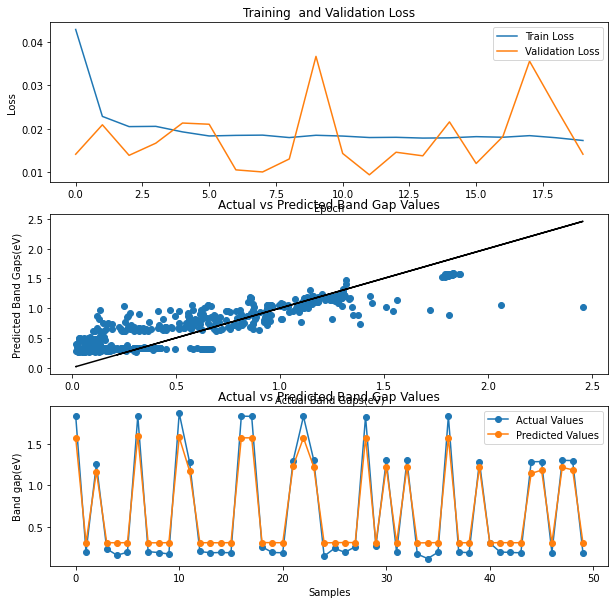

In [98]:
class GNNModel(nn.Module):
    def __init__(self, node_dim=NODE_DIM, edge_dim=EDGE_DIM, hidden_dim=HIDDEN_DIM, embed_dim=EMBED_DIM, global_dim=U_DIM):
        super().__init__()

        # Edge network for NNConv: maps each edge_attr to a weight matrix
        self.edge_mlp = nn.Sequential(
            nn.Linear(edge_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, node_dim * hidden_dim),
        )

        # First message-passing layer
        self.conv1 = NNConv(node_dim, hidden_dim, self.edge_mlp, aggr='mean')

        # Second message-passing layer using CGConv
        self.conv2 = CGConv(hidden_dim, edge_dim, aggr='mean')
        # self.conv3 = CGConv(hidden_dim, edge_dim, aggr='mean')

        # Embed the graph-level global features
        self.global_embed = nn.Linear(global_dim, embed_dim)

        # Final MLP head
        self.fc = nn.Sequential(
            nn.Linear(hidden_dim + embed_dim, 128),
            nn.Dropout(0.2),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.Dropout(0.2),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.Dropout(0.2),
            # NO ReLU here - allow both positive and negative outputs
            nn.Linear(32, 1)
        )

    def forward(self, data):
        x, edge_index, edge_attr, batch, u = (
            data.x,
            data.edge_index,
            data.edge_attr,
            data.batch,
            data.u,
        )

        x = F.relu(self.conv1(x, edge_index, edge_attr))
        x = F.relu(self.conv2(x, edge_index, edge_attr))
        # x = F.relu(self.conv3(x, edge_index, edge_attr))

        x = global_mean_pool(x, batch)
        u = self.global_embed(u)

        x = torch.cat([x, u], dim=1)
        return self.fc(x)

GNN_model = GNNModel().to(device)

# optimizer with L2 regularization to prevent overfitting
optimizer = torch.optim.Adam(GNN_model.parameters(), lr=0.001, weight_decay=1e-4)

train_losses, val_losses = train(GNN_model, train_loader, val_loader, epochs=20, optimizer=optimizer, loss_fn=loss_fn)
get_graphs(train_losses, val_losses, GNN_model)

# CVAE

## Data Preparation

In [6]:
# unique_defect_sites = comb_df['defect_site'].nunique()
MAX_POINTS = max(comb_df['defect_sites'])

In [10]:
# Defects cloud to padded tensor
def cloud_to_tensor(defect_cloud, max_points=MAX_POINTS):
    rows = []
    for a_site in defect_cloud:
        fc = a_site.frac_coords.tolist()

        required = [
            a_site.properties["original_Z"]/94,
            a_site.properties["new_Z"]/94,
            a_site.properties["substitution_defect"],
            a_site.properties["vacancy_defect"]
        ]

        combined = fc + required

        rows.append(combined)

    while len(rows) < max_points:
        rows.append([0.0]*7)

    return torch.tensor(rows, dtype=torch.float32)

# Test
test_tensor = cloud_to_tensor(defects_structure)
test_tensor

tensor([[0.1667, 0.7083, 0.1927, 0.0532, 0.0638, 1.0000, 0.0000],
        [0.9167, 0.8333, 0.1927, 0.0532, 0.0638, 1.0000, 0.0000],
        [0.9580, 0.7920, 0.1930, 0.0745, 0.0000, 0.0000, 1.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0

In [11]:
def tensor_to_cloud(tensor_cloud, threshold = 0.1):

    points = []
    for row in tensor_cloud:
        row = row.detach().cpu()
        if row.norm() < threshold:
            continue  # padding row
        frac_coords = row[:3].clamp(0.0, 1.0).numpy()

        Zp = int((row[3] * 94).round().clamp(0, 94).item())
        Zd = int((row[4] * 94).round().clamp(0, 94).item())

        sub_defect = row[5].item()
        vac_defect = row[6].item()

        if sub_defect:
            defect_type = "substitution"
        elif vac_defect:
            defect_type = "vacancy"

        points.append({
            "fractional_coords": frac_coords,
            "Z_pristine":  Zp,
            "Z_defective": Zd,
            "defect_type":  defect_type,
        })
    return points

test_cloud = tensor_to_cloud(test_tensor)
test_cloud


[{'fractional_coords': array([0.166667  , 0.708333  , 0.19268163], dtype=float32),
  'Z_pristine': 5,
  'Z_defective': 6,
  'defect_type': 'substitution'},
 {'fractional_coords': array([0.916667  , 0.833333  , 0.19268163], dtype=float32),
  'Z_pristine': 5,
  'Z_defective': 6,
  'defect_type': 'substitution'},
 {'fractional_coords': array([0.958, 0.792, 0.193], dtype=float32),
  'Z_pristine': 7,
  'Z_defective': 0,
  'defect_type': 'vacancy'}]

In [ ]:
def func_1(reference_structure):
    # Node features for each atom in pristine structure
    node_feats = []
    for site in reference_structure.sites:
        el = site.specie
        node_feats.append([
            el.Z / 94.0,
            el.X / 4.0 if el.X else 0.0,
            el.atomic_radius if el.atomic_radius else 0.0,
            el.row / 9.0,
            el.group / 18.0,
        ])
    node_features = torch.tensor(node_feats, dtype=torch.float32)


    # Build edge index from radius graph with cutoff of 5 Å
    src, dst = [], []
    coords = np.array([s.coords for s in reference_structure.sites])
    for i in range(len(reference_structure.sites)):
        for j in range(len(reference_structure.sites)):
            if i == j:
                continue
            dist = np.linalg.norm(coords[i] - coords[j])
            if dist < 5.0:
                src.append(i)
                dst.append(j)
    edge_index = torch.tensor([src, dst], dtype=torch.long)

    return{
        "node_features": node_features,
        "edge_index":    edge_index
    }


# band_gap_value = sample_row["band_gap_value"]
output = func_1(reference_structure)
output

{'node_features': tensor([[0.0532, 0.5100, 0.8500, 0.2222, 0.7222],
         [0.0532, 0.5100, 0.8500, 0.2222, 0.7222],
         [0.0532, 0.5100, 0.8500, 0.2222, 0.7222],
         [0.0532, 0.5100, 0.8500, 0.2222, 0.7222],
         [0.0532, 0.5100, 0.8500, 0.2222, 0.7222],
         [0.0532, 0.5100, 0.8500, 0.2222, 0.7222],
         [0.0532, 0.5100, 0.8500, 0.2222, 0.7222],
         [0.0532, 0.5100, 0.8500, 0.2222, 0.7222],
         [0.0532, 0.5100, 0.8500, 0.2222, 0.7222],
         [0.0532, 0.5100, 0.8500, 0.2222, 0.7222],
         [0.0532, 0.5100, 0.8500, 0.2222, 0.7222],
         [0.0532, 0.5100, 0.8500, 0.2222, 0.7222],
         [0.0532, 0.5100, 0.8500, 0.2222, 0.7222],
         [0.0532, 0.5100, 0.8500, 0.2222, 0.7222],
         [0.0532, 0.5100, 0.8500, 0.2222, 0.7222],
         [0.0532, 0.5100, 0.8500, 0.2222, 0.7222],
         [0.0532, 0.5100, 0.8500, 0.2222, 0.7222],
         [0.0532, 0.5100, 0.8500, 0.2222, 0.7222],
         [0.0532, 0.5100, 0.8500, 0.2222, 0.7222],
         [0.05

In [13]:
sample_dataset = comb_df[comb_df["dataset_material"]!= "low_MoS2"].reset_index(drop=True)
sample_dataset = sample_dataset[sample_dataset["dataset_material"]!= "low_WSe2"].reset_index(drop=True)

In [14]:
sample_train, sample_val = train_test_split(sample_dataset, test_size=0.3, random_state=42, stratify= sample_dataset['strata'])
sample_train.reset_index(drop=True, inplace=True)
sample_val.reset_index(drop=True, inplace=True)


In [15]:
# import pandas as pd
import numpy as np
from pymatgen.core import Structure, PeriodicSite, DummySpecie 

def struct_to_dict(structure):
    rounded_coords = np.round(structure.frac_coords, 3)
    return {tuple(coord): site for coord, site in zip(rounded_coords, structure.sites)}


def get_defects_structure(defective_struct, reference_struct):
    # mindnn = MinimumDistanceNN()
    # struct to dict
    defective_dict = struct_to_dict(defective_struct)
    reference_dict = struct_to_dict(reference_struct)

    # Get lattice of defective structure
    structure_lattice = defective_struct.lattice

    # List to add all defect sites
    defects_list = []

    # Dictionary to hold properties of each defect site
    defects_properties = {}

    ref_index = 0

    for ref_coord, ref_site in reference_dict.items():
        # Use the reference coordinates to get the defective site
        ref_index = ref_index + 1

        def_site = defective_dict.get(ref_coord)

        if def_site:  # The site is found in both the reference structure and the defective structure
            # But are the species the same?
            ref_specie = ref_site.specie
            def_specie = def_site.specie
            if ref_specie != def_specie:  # Substitution
                # Add site to defects list
                defects_list.append(def_site)

                # Get atomic number change and defect type
                add_property = {
                    "original_Z":ref_specie.Z,
                    "new_Z": def_specie.Z,
                    "vacancy_defect": 0.0,
                    "substitution_defect": 1.0,
                }

                defects_properties[def_site] = add_property

        else: # the site from ref_structure is not found in defective structure
            # This means that the site is a vacancy site
            # Add site to defective structure
            vacant_site = PeriodicSite(
                species= DummySpecie(),
                coords= ref_coord,
                coords_are_cartesian= False,
                lattice= structure_lattice
                )

            # Add site to defects list
            defects_list.append(vacant_site)

            ref_specie = ref_site.specie

            # Get atomic number change and defect type
            add_property={
                "original_Z":ref_specie.Z,
                "new_Z": 0,
                "vacancy_defect": 1.0,
                "substitution_defect": 0.0,

            }
            defects_properties[vacant_site] = add_property

    # create a defects structure
    defects_struct = Structure.from_sites(defects_list)

    # Add properties to defects structure
    for a_site in defects_struct.sites:
        if a_site in defects_properties.keys():
            a_site.properties.update(defects_properties[a_site])
        else:
            pass

    return defects_struct



In [ ]:
def fast_cvae_data(dataset):
    data_list = []
    unique_materials = dataset["dataset_material"].unique()
    # run = 0
    # whole_dataset = len(dataset)

    for material in unique_materials:
        subset = dataset[dataset["dataset_material"] == material].reset_index(drop=True)
        reference_structure = Structure.from_file(f"{final_data}/ref_cifs/{material}.cif")

        # Get nodes and edges of pristine strructure
        pristine_nodes_edges = func_1(reference_structure)

        for index, row in subset.iterrows():
            id = row["_id"]
            bgv = row["band_gap_value"]
            defective_structure = Structure.from_file(f"{original_data}/{material}/cifs/{id}.cif")

            defects_only_structure = get_defects_structure(defective_structure, reference_structure)

            # Defect cloud as tensor
            tensor_cloud = cloud_to_tensor(defects_only_structure)

            # band_gap
            band_gap = torch.tensor([bgv], dtype=torch.float32)

            data = Data(
                node_features = pristine_nodes_edges["node_features"],
                edge_index = pristine_nodes_edges["edge_index"],
                defect_cloud = tensor_cloud,
                band_gap = band_gap
            )

            data_list.append(data)

    return data_list

train_dataset = fast_cvae_data(sample_train)
val_dataset = fast_cvae_data(sample_val)
# for_example = fast_cvae_data(sample_dataset.sample(n=50))

/home/amutua/.local/lib/python3.10/site-packages/pymatgen/core/structure.py:3109: UserWarning: Issues encountered while parsing CIF: 41 fractional coordinates rounded to ideal values to avoid issues with finite precision.
  struct = parser.parse_structures(primitive=primitive)[0]
/home/amutua/.local/lib/python3.10/site-packages/pymatgen/core/structure.py:3109: UserWarning: Issues encountered while parsing CIF: 42 fractional coordinates rounded to ideal values to avoid issues with finite precision.
  struct = parser.parse_structures(primitive=primitive)[0]
/home/amutua/.local/lib/python3.10/site-packages/pymatgen/core/structure.py:3109: UserWarning: Issues encountered while parsing CIF: 22 fractional coordinates rounded to ideal values to avoid issues with finite precision.
  struct = parser.parse_structures(primitive=primitive)[0]
/home/amutua/.local/lib/python3.10/site-packages/pymatgen/core/structure.py:3109: UserWarning: Issues encountered while parsing CIF: 20 fractional coordinate

In [22]:
def collate_fn(batch):
    batch_node_features = []
    batch_edge_index = []
    batch_defect_cloud = []
    batch_band_gap = []

    node_offset = 0
    for item in batch:
        batch_node_features.append(item["node_features"])
        batch_defect_cloud.append(item["defect_cloud"])
        batch_band_gap.append(item["band_gap"])

        edge_index = item["edge_index"] + node_offset
        batch_edge_index.append(edge_index)

        node_offset += item["node_features"].shape[0]

    return {
        "node_features": torch.cat(batch_node_features, dim=0),
        "edge_index": torch.cat(batch_edge_index, dim=1),
        "defect_cloud": torch.stack(batch_defect_cloud, dim=0),
        "band_gap": torch.stack(batch_band_gap, dim=0)
    }

In [24]:
test_loader = DataLoader(train_dataset, batch_size=8, shuffle=True, collate_fn=collate_fn)

for batch in test_loader:
    print(batch)
    break

DataBatch(edge_index=[2, 21876], node_features=[1376, 5], defect_cloud=[192, 7], band_gap=[8], batch=[1376], ptr=[9])


In [50]:
NODE_DIM = train_dataset[0].node_features.shape[1]
POINT_DIM = train_dataset[0].defect_cloud.shape[1]
HIDDEN_DIM = 128
LATENT_DIM = 32
MAX_POINTS = int(MAX_POINTS)

## The model architecture

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
#  ENCODER
class PristineGNNEncoder(nn.Module):
    def __init__(self, node_dim = NODE_DIM, hidden_dim = HIDDEN_DIM, latent_dim = LATENT_DIM, n_max = MAX_POINTS, point_dim = POINT_DIM):
        super().__init__()

        self.conv1 = GCNConv(node_dim, hidden_dim)
        self.conv2 = GCNConv(hidden_dim, hidden_dim)

        cloud_flat = n_max * point_dim
        self.fc_combine = nn.Linear(hidden_dim * 2 + cloud_flat, hidden_dim)

        self.fc_mu      = nn.Linear(hidden_dim, latent_dim)
        self.fc_log_var = nn.Linear(hidden_dim, latent_dim)

    # def forward(self, data):
    def forward(self,
            node_features: torch.Tensor,  # (total_nodes, node_dim)
            edge_index:    torch.Tensor,  # (2, total_edges)
            defect_cloud:  torch.Tensor,  # (B * n_max, point_dim)
            batch:         torch.Tensor   # (total_nodes,) – node→graph mapping
            ) -> tuple[torch.Tensor, torch.Tensor]:
        '''node_features = data.node_features
        edge_index = data.edge_index
        defect_cloud = data.defectt_cloud
        batch = data.batch '''

        h = F.relu(self.conv1(node_features, edge_index))
        h = F.relu(self.conv2(h, edge_index))

        h_mean = global_mean_pool(h, batch)
        h_max  = global_max_pool(h, batch)
        h_graph = torch.cat([h_mean, h_max], dim=-1)

        B = h_graph.shape[0]
        cloud_flat = defect_cloud.view(B, -1)  # (B, n_max*point_dim)

        combined = torch.cat([h_graph, cloud_flat], dim=-1)
        hidden   = F.relu(self.fc_combine(combined))

        mu      = self.fc_mu(hidden)       # (B, latent_dim)
        log_var = self.fc_log_var(hidden)  # (B, latent_dim)
        return mu, log_var


# DECODER
class DefectCloudDecoder(nn.Module):
    def __init__(self,hidden_dim = HIDDEN_DIM, latent_dim = LATENT_DIM, n_max = MAX_POINTS, point_dim = POINT_DIM):
        super().__init__()
        self.n_max     = n_max
        self.point_dim = point_dim

        # +1 for band gap conditioning
        self.net = nn.Sequential(
            nn.Linear(latent_dim + 1, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim * 2),
            nn.ReLU(),
            nn.Linear(hidden_dim * 2, n_max * point_dim),
        )

    def forward(self, z, band_gap):

        if band_gap.dim() == 1:
            band_gap = band_gap.unsqueeze(-1)

        inp = torch.cat([z, band_gap], dim=-1)
        out = self.net(inp)
        out = out.view(-1, self.n_max, self.point_dim)

        # Apply activations per channel
        coords  = torch.sigmoid(out[..., :3])
        z_vals  = torch.sigmoid(out[..., 3:5])
        logits  = out[..., 5:]

        return torch.cat([coords, z_vals, logits], dim=-1)


# ACTUAL MODEL(ENCODER + DECODER)
class DefectCVAE(nn.Module):
    def __init__(self, node_dim = NODE_DIM, hidden_dim = HIDDEN_DIM, latent_dim = LATENT_DIM, n_max = MAX_POINTS, point_dim = POINT_DIM):

        super().__init__()
        self.latent_dim = latent_dim
        self.encoder = PristineGNNEncoder(node_dim, hidden_dim, latent_dim, n_max, point_dim)
        self.decoder = DefectCloudDecoder(hidden_dim,latent_dim, n_max, point_dim)

    def reparameterize(self, mu, log_var):
        if self.training:
            std = torch.exp(0.5 * log_var)
            eps = torch.randn_like(std)
            return mu + eps * std
        return mu

    def forward(self, data):
        mu, log_var = self.encoder(data.node_features, data.edge_index, data.defect_cloud, data.batch)
        z = self.reparameterize(mu, log_var)
        recon = self.decoder(z, data.band_gap)
        return recon, mu, log_var

    @torch.no_grad()
    def generate(self, target_band_gap, n_samples, device = "cpu"):
        self.eval()
        z = torch.randn(n_samples, self.latent_dim, device=device)
        bg = torch.full((n_samples,), target_band_gap,
                        dtype=torch.float32, device=device)
        cloud_tensors = self.decoder(z, bg)

        results = []
        for i in range(n_samples):
            points = tensor_to_cloud(cloud_tensors[i])
            results.append(points)
        return results

In [32]:
# Loss function for cvae
def cvae_loss(recon_cloud, target_cloud, mu, log_var, beta=1e-3):
    # Continuous features: coords + Z values
    mse_loss = F.mse_loss(recon_cloud[..., :5], target_cloud[..., :5])

    # Type logits: everything from index 5 onward (works for 2 or 4 channels)
    n_type_channels = recon_cloud.shape[-1] - 5
    recon_logits   = recon_cloud[..., 5:]
    target_classes = target_cloud[..., 5:].argmax(dim=-1)

    mask = (target_cloud.norm(dim=-1) > 0.01)
    if mask.any():
        ce_loss = F.cross_entropy(recon_logits[mask], target_classes[mask])
    else:
        ce_loss = torch.tensor(0.0, requires_grad=True)

    kl_loss = -0.5 * torch.mean(1 + log_var - mu.pow(2) - log_var.exp())

    total = mse_loss + ce_loss + beta * kl_loss
    return {"loss": total, "mse": mse_loss, "ce": ce_loss, "kl": kl_loss}

In [61]:
# Loaders
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False, collate_fn=collate_fn)

# Parameters for training model
model = DefectCVAE().to(device)
EPOCHS = 20
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
beta = 1e-3
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=30, gamma=0.5)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=0.001)
losses_dict = {"train_loss": [], "val_loss": [], "kl": [], "mse": []}

# Validate function
def validate(model, loader, beta):
    # Model in evaluation mode
    model.eval()
    
    totals = {"loss": 0.0, "mse": 0.0, "ce": 0.0, "kl": 0.0}
    with torch.no_grad():
        for batch in loader:
            # batch = {k: v.to(device) for k, v in batch.items()}
            recon, mu, log_var = model(batch.to(device))

            B = batch.band_gap.shape[0]
            target_cloud = batch.defect_cloud.view(B, -1, batch.defect_cloud.shape[-1])
            losses = cvae_loss(recon, target_cloud, mu, log_var, beta)
            # losses = cvae_loss(recon, batch["defect_cloud"], mu, log_var, beta)
            for k in totals:
                totals[k] += losses[k].item()

        n = max(len(loader), 1)
        return {k: v / n for k, v in totals.items()}

# Training loop
for epoch in range(1, EPOCHS+1):
    # Put model in training mode at the start of each epoch
    model.train()

    # Parameters for each epoch
    total_losses = {"loss": 0.0, "mse": 0.0, "ce": 0.0, "kl": 0.0}
    current_beta = beta * min(1.0, epoch / EPOCHS)

    for batch in train_loader:
        optimizer.zero_grad()

        # Output of the model
        recon, mu, log_var = model(batch.to(device))

        B = batch.band_gap.shape[0]
        target_cloud = batch.defect_cloud.view(B, -1, batch.defect_cloud.shape[-1])
        losses = cvae_loss(recon, target_cloud, mu, log_var, current_beta)
        # losses = cvae_loss(recon, batch["defect_cloud"], mu, log_var, current_beta)
        losses["loss"].backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        # Add losses to totals
        for k in total_losses:
            total_losses[k] += losses[k].item()

    n = max(len(train_loader), 1)
    final_dict = {k: v / n for k, v in total_losses.items()}

    # Validate at the end of each epoch
    val_losses = validate(model, val_loader, current_beta)
    scheduler.step()

    losses_dict["train_loss"].append(final_dict["loss"])
    losses_dict["val_loss"].append(val_losses["loss"])
    losses_dict["kl"].append(final_dict["kl"])
    losses_dict["mse"].append(final_dict["mse"])

    print(f"Epoch {epoch:4d}| train {final_dict['loss']:.4f} | val {val_losses['loss']:.4f} | KL {final_dict['kl']:.4f} | MSE {final_dict['mse']:.4f}")

Epoch    1| train 0.7132 | val 0.5938 | KL 0.4551 | MSE 0.0486
Epoch    2| train 0.4656 | val 0.3908 | KL 2.2310 | MSE 0.0346
Epoch    3| train 0.3327 | val 0.3186 | KL 2.6670 | MSE 0.0319
Epoch    4| train 0.2885 | val 0.2819 | KL 2.7917 | MSE 0.0348
Epoch    5| train 0.2623 | val 0.2731 | KL 2.8416 | MSE 0.0347
Epoch    6| train 0.2489 | val 0.2608 | KL 2.8552 | MSE 0.0313
Epoch    7| train 0.2348 | val 0.2632 | KL 2.9619 | MSE 0.0297
Epoch    8| train 0.2189 | val 0.2559 | KL 2.9243 | MSE 0.0292
Epoch    9| train 0.2018 | val 0.2372 | KL 3.0239 | MSE 0.0298
Epoch   10| train 0.1811 | val 0.2257 | KL 3.0630 | MSE 0.0301
Epoch   11| train 0.1701 | val 0.2182 | KL 3.0303 | MSE 0.0303
Epoch   12| train 0.1576 | val 0.2091 | KL 3.1100 | MSE 0.0302
Epoch   13| train 0.1451 | val 0.2155 | KL 3.1708 | MSE 0.0297
Epoch   14| train 0.1351 | val 0.2109 | KL 3.1459 | MSE 0.0294
Epoch   15| train 0.1270 | val 0.2209 | KL 3.1366 | MSE 0.0290
Epoch   16| train 0.1177 | val 0.2063 | KL 3.0596 | MSE

## Inverse Design

In [59]:

def apply_defects_to_structure(pristine, defect_points):

    COORD_TOL = 0.3   # fractional-coordinate tolerance — generous for generated coords

    defective = pristine.copy()
    vacancy_indices = []

    for dp in defect_points:
        defect_frac = np.array(dp["fractional_coords"]) % 1.0  # wrap to [0,1]
        dtype       = dp["defect_type"]
        Zd          = dp["Z_defective"]

        best_idx, best_dist = None, float("inf")
        for idx, site in enumerate(defective):
            delta = defect_frac - site.frac_coords
            delta -= np.round(delta)          # minimum image convention
            dist = np.linalg.norm(delta)
            if dist < best_dist:
                best_dist, best_idx = dist, idx

        if best_idx is None or best_dist > COORD_TOL:
            print(f"  Warning: no site found within tol={COORD_TOL} for "
                f"{dtype} at {np.round(defect_frac, 3)} "
                f"(closest={best_dist:.3f}). Skipping this defect.")
            continue

        if dtype == "vacancy":
            if best_idx not in vacancy_indices:
                vacancy_indices.append(best_idx)

        elif dtype in ("substitution", "antisite") and Zd > 0:
            elem = Element.from_Z(Zd)
            defective[best_idx] = PeriodicSite(
                elem,
                defective[best_idx].frac_coords,
                defective[best_idx].lattice,
            )

    # Remove vacancies in reverse order so indices stay valid
    for idx in sorted(vacancy_indices, reverse=True):
        defective.remove_sites([idx])

    return defective


def inverse_design(model, pristine, target_band_gap, n_candidates, device):
    model.eval()
    model = model.to(device)

    # Generate defect clouds
    defect_clouds = model.generate(target_band_gap, n_candidates, device)

    # Apply each cloud to the pristine structure
    candidates = []
    for i, cloud in enumerate(defect_clouds):
        if not cloud:
            print(f"  Candidate {i+1}: no defects generated (empty cloud), skipping.")
            continue
        try:
            defective = apply_defects_to_structure(pristine, cloud)
            candidates.append(defective)
            print(f"  Candidate {i+1}: {len(cloud)} defect(s) | "
                f"{len(defective)} atoms | "
                f"types: {[d['defect_type'] for d in cloud]}")
        except Exception as e:
            print(f"  Candidate {i+1}: failed to apply defects ({e})")

    return candidates


candidates = inverse_design(
    model           = model,
    pristine        = reference_structure,
    target_band_gap = 1.5,
    n_candidates    = 3,
    device          = device,
)

  Candidate 1: 24 defect(s) | 128 atoms | types: ['substitution', 'substitution', 'substitution', 'substitution', 'substitution', 'substitution', 'substitution', 'substitution', 'substitution', 'substitution', 'substitution', 'substitution', 'substitution', 'substitution', 'substitution', 'substitution', 'substitution', 'substitution', 'substitution', 'substitution', 'substitution', 'substitution', 'substitution', 'substitution']
  Candidate 2: 24 defect(s) | 128 atoms | types: ['substitution', 'substitution', 'substitution', 'substitution', 'substitution', 'substitution', 'substitution', 'substitution', 'substitution', 'substitution', 'substitution', 'substitution', 'substitution', 'substitution', 'substitution', 'substitution', 'substitution', 'substitution', 'substitution', 'substitution', 'substitution', 'substitution', 'substitution', 'substitution']
  Candidate 3: 24 defect(s) | 128 atoms | types: ['substitution', 'substitution', 'substitution', 'substitution', 'substitution', 's

In [60]:
print(candidates[0])

Full Formula (Li1 Ti2 Be1 Al1 Ge1 B57 H2 C1 N59 Cl1 F2)
Reduced Formula: LiTi2BeAlGeB57H2CN59ClF2
abc   :  20.099428  20.099428  20.000000
angles:  90.000000  90.000000 120.000012
pbc   :       True       True       True
Sites (128)
  #  SP           a         b         c
---  ----  --------  --------  --------
  0  H     0.041667  0.083333  0.192682
  1  B     0.041667  0.208333  0.192682
  2  B     0.041667  0.333333  0.192682
  3  B     0.041667  0.458333  0.192682
  4  B     0.041667  0.583333  0.192682
  5  B     0.041667  0.708333  0.192682
  6  B     0.041667  0.833333  0.192682
  7  B     0.041667  0.958333  0.192682
  8  H     0.166667  0.083333  0.192682
  9  B     0.166667  0.208333  0.192682
 10  B     0.166667  0.333333  0.192682
 11  B     0.166667  0.458333  0.192682
 12  B     0.166667  0.583333  0.192682
 13  B     0.166667  0.708333  0.192682
 14  B     0.166667  0.833333  0.192682
 15  B     0.166667  0.958333  0.192682
 16  B     0.291667  0.083333  0.192682
 17  B 

# Confirm Band gap of generated Structure